<a href="https://colab.research.google.com/github/jaewoenlee/ML/blob/main/threshold_mse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Neural Network Example: Threshold Classification with MSE

Classify numbers as 0 for x < 3 and 1 for x >= 3.

All four implementations use:
- Sigmoid activation
- Mean Squared Error (MSE)
- Gradient Descent / Stochastic Gradient Descent
- Learning rate = 0.1
- 1000 epochs

Implementations: Pure Python, TensorFlow, Keras, and PyTorch.

## 1. Pure Python

epoch = 0 MSE = 0.25
epoch = 100 MSE = 0.13250677147080503
epoch = 200 MSE = 0.09934557186394662
epoch = 300 MSE = 0.08169246491165395
epoch = 400 MSE = 0.07081220939820923
epoch = 500 MSE = 0.06335445337081852
epoch = 600 MSE = 0.057852514354228224
epoch = 700 MSE = 0.053575969526496126
epoch = 800 MSE = 0.05012195398542738
epoch = 900 MSE = 0.04724995816776479

w = 1.3391202966946125
b = -3.1291902592453162
0 0.041919115727701524 -> 0
1 0.1430641460813189 -> 0
2 0.3891349982230324 -> 0
3 0.7085125107764114 -> 1
4 0.9026736157644722 -> 1
5 0.9725194401288506 -> 1
boundary = 2.3367506765218797


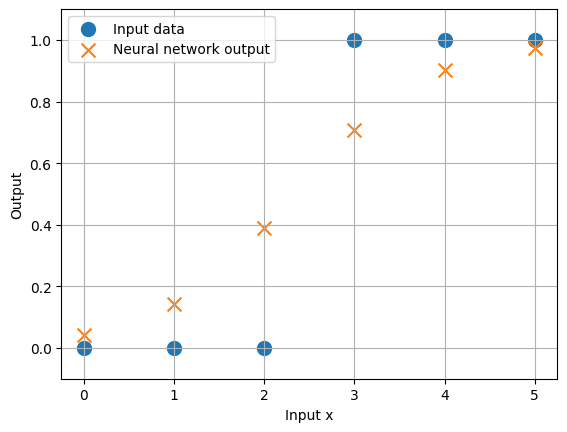

In [1]:
import math
import matplotlib.pyplot as plt

# Input data and labels: output 0 for x < 3, output 1 for x >= 3
X = [0, 1, 2, 3, 4, 5]
Y = [0, 0, 0, 1, 1, 1]

# Initialize weight, bias, and learning rate
w = 0.0
b = 0.0
learning_rate = 0.1

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# Train w and b using gradient descent with MSE
for epoch in range(1000):
    dw = 0.0
    db = 0.0
    mse = 0.0

    for x, y in zip(X, Y):
        # Forward propagation
        z = w * x + b
        y_pred = sigmoid(z)

        # Prediction error
        error = y_pred - y
        mse += error ** 2

        # Sigmoid derivative
        sigmoid_derivative = y_pred * (1 - y_pred)

        # Gradients of MSE
        dw += 2 * error * sigmoid_derivative * x
        db += 2 * error * sigmoid_derivative

    # Average over all samples
    mse /= len(X)
    dw /= len(X)
    db /= len(X)

    # Gradient descent update
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 100 == 0:
        print("epoch =", epoch, "MSE =", mse)

# Print learned parameters
print("\nw =", w)
print("b =", b)

# Test each input and collect predictions
predictions_for_plot = []
for x in X:
    y_pred = sigmoid(w * x + b)
    predictions_for_plot.append(y_pred)
    result = 1 if y_pred >= 0.5 else 0
    print(x, y_pred, "->", result)

# Decision boundary from wx + b = 0
print("boundary =", -b / w)

# Plot
plt.scatter(X, Y, marker='o', s=100, label='Input data')
plt.scatter(X, predictions_for_plot, marker='x', s=100, label='Neural network output')
plt.xlabel("Input x")
plt.ylabel("Output")
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()

## 2. TensorFlow

In [2]:
import tensorflow as tf

# Input data and labels
X = tf.constant([[0.], [1.], [2.], [3.], [4.], [5.]], dtype=tf.float32)
Y = tf.constant([[0.], [0.], [0.], [1.], [1.], [1.]], dtype=tf.float32)

# Define trainable weight and bias
w = tf.Variable([[0.0]], dtype=tf.float32)
b = tf.Variable([0.0], dtype=tf.float32)
learning_rate = 0.1

# Train using gradient descent with MSE
for epoch in range(1000):
    with tf.GradientTape() as tape:
        y_pred = tf.sigmoid(tf.matmul(X, w) + b)

        # Mean Squared Error
        loss = tf.reduce_mean(tf.square(y_pred - Y))

    # Automatic differentiation
    dw, db = tape.gradient(loss, [w, b])

    # Gradient descent update
    w.assign_sub(learning_rate * dw)
    b.assign_sub(learning_rate * db)

    if epoch % 100 == 0:
        print("epoch =", epoch, "MSE =", float(loss.numpy()))

# Predict using the trained model
y_pred = tf.sigmoid(tf.matmul(X, w) + b)

# Print results
print("\nw =", w.numpy())
print("b =", b.numpy())
print("Predicted probabilities:")
print(y_pred.numpy())
print("Predicted classes:")
print((y_pred.numpy() >= 0.5).astype(int))

# Decision boundary
print("boundary =", -b.numpy()[0] / w.numpy()[0, 0])

epoch = 0 MSE = 0.25
epoch = 100 MSE = 0.13250677287578583
epoch = 200 MSE = 0.09934557229280472
epoch = 300 MSE = 0.08169249445199966
epoch = 400 MSE = 0.07081222534179688
epoch = 500 MSE = 0.0633544921875
epoch = 600 MSE = 0.057852551341056824
epoch = 700 MSE = 0.05357600748538971
epoch = 800 MSE = 0.050121989101171494
epoch = 900 MSE = 0.04724998399615288

w = [[1.3391192]]
b = [-3.129188]
Predicted probabilities:
[[0.04191921]
 [0.14306429]
 [0.38913497]
 [0.70851237]
 [0.9026734 ]
 [0.97251934]]
Predicted classes:
[[0]
 [0]
 [0]
 [1]
 [1]
 [1]]
boundary = 2.336751


## 3. Keras

In [3]:
import numpy as np
from tensorflow import keras

# Input data and labels
X = np.array([[0], [1], [2], [3], [4], [5]], dtype=np.float32)
Y = np.array([[0], [0], [0], [1], [1], [1]], dtype=np.float32)

# Create a neural network with one input and one output neuron
# Zero initialization is used so that all four examples start from the same w and b.
model = keras.Sequential([
    keras.Input(shape=(1,)),
    keras.layers.Dense(
        1,
        activation='sigmoid',
        kernel_initializer='zeros',
        bias_initializer='zeros'
    )
])

# Use SGD and MSE
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='mse'
)

# Train the neural network
history = model.fit(X, Y, epochs=1000, verbose=0)

# Predict outputs
prediction = model.predict(X, verbose=0)

# Get the learned weight and bias
w, b = model.layers[0].get_weights()

# Print results
print("Final MSE =", history.history['loss'][-1])
print("Predicted probabilities:")
print(prediction)
print("Predicted classes:")
print((prediction >= 0.5).astype(int))
print("w =", w)
print("b =", b)

# Decision boundary
print("boundary =", -b[0] / w[0, 0])

Final MSE = 0.04482989385724068
Predicted probabilities:
[[0.04191921]
 [0.14306429]
 [0.38913497]
 [0.70851237]
 [0.9026734 ]
 [0.97251934]]
Predicted classes:
[[0]
 [0]
 [0]
 [1]
 [1]
 [1]]
w = [[1.3391192]]
b = [-3.129188]
boundary = 2.336751


## 4. PyTorch

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# Input data and labels
X = torch.tensor([[0.], [1.], [2.], [3.], [4.], [5.]], dtype=torch.float32)
Y = torch.tensor([[0.], [0.], [0.], [1.], [1.], [1.]], dtype=torch.float32)

# One linear neuron followed by sigmoid
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

# Initialize weight and bias to zero for comparison with the other versions
with torch.no_grad():
    model[0].weight.fill_(0.0)
    model[0].bias.fill_(0.0)

# MSE loss and SGD optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Train using gradient descent
for epoch in range(1000):
    # Forward propagation
    y_pred = model(X)

    # Mean Squared Error
    loss = criterion(y_pred, Y)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Gradient descent update
    optimizer.step()

    if epoch % 100 == 0:
        print("epoch =", epoch, "MSE =", loss.item())

# Final prediction
with torch.no_grad():
    prediction = model(X)

# Get learned weight and bias
w = model[0].weight.item()
b = model[0].bias.item()

# Print results
print("\nFinal MSE =", criterion(prediction, Y).item())
print("Predicted probabilities:")
print(prediction.numpy())
print("Predicted classes:")
print((prediction.numpy() >= 0.5).astype(int))
print("w =", w)
print("b =", b)

# Decision boundary
print("boundary =", -b / w)

epoch = 0 MSE = 0.25
epoch = 100 MSE = 0.13250677287578583
epoch = 200 MSE = 0.09934557229280472
epoch = 300 MSE = 0.08169248700141907
epoch = 400 MSE = 0.07081222534179688
epoch = 500 MSE = 0.0633544996380806
epoch = 600 MSE = 0.057852551341056824
epoch = 700 MSE = 0.05357600376009941
epoch = 800 MSE = 0.0501219816505909
epoch = 900 MSE = 0.04724998399615288

Final MSE = 0.044807229191064835
Predicted probabilities:
[[0.0419192 ]
 [0.14306429]
 [0.389135  ]
 [0.7085123 ]
 [0.9026734 ]
 [0.9725194 ]]
Predicted classes:
[[0]
 [0]
 [0]
 [1]
 [1]
 [1]]
w = 1.3391191959381104
b = -3.129188060760498
boundary = 2.3367509555923944


## Gradient used in all versions

For one sample:

- prediction = sigmoid(w*x + b)
- error = prediction - y
- MSE contribution = error²

The Pure Python version calculates the gradient explicitly. TensorFlow and PyTorch calculate the same gradient automatically, while Keras performs the same process internally through `model.fit()`.

Because all four versions start from w = 0 and b = 0 and use the same learning rate and MSE loss, their learned parameters should be very close.